In [5]:
#importing libraries & loading dataset
import pandas as pd   #deals with panel data / data analysis
import numpy as np    #numerical operations
import matplotlib.pyplot as plt  #basic graphs
import seaborn as sns   #better statistical visualizations

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
#Understanding & cleaning data
print(df.shape)     #dataset shape
print(df.info())      #dataset info  
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.drop_duplicates(inplace=True))  #inplace operation modifies data directly within the existing memory address of the object, rather than creating a new object.

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestro

In [7]:
df.describe()    

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
#PREPROCESSING
from sklearn.preprocessing import LabelEncoder

binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for cols in binary_cols:
    df[cols] = df[cols].map({"yes": 1, "no": 0})

le = LabelEncoder()

df["furnishingstatus"] = le.fit_transform(df["furnishingstatus"])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int32
dtypes: int32(1), int64(12)
memory usage: 53.4 KB


In [10]:
#SEPARATING FEATURES AND TARGET

X = df.drop("price", axis=1)
y = df["price"]

X.head()
print(y.head())
print(X.shape)
print(y.shape)

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64
(545, 12)
(545,)


In [11]:
#Train-test-Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [13]:
#training LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)
print(X_test,y_pred[:5])

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
316  5900         4          2        2         0          0         1   
77   6500         3          2        3         1          0         0   
360  4040         2          1        1         1          0         0   
90   5000         3          1        2         1          0         0   
493  3960         3          1        1         1          0         0   
..    ...       ...        ...      ...       ...        ...       ...   
15   6000         4          1        2         1          0         1   
357  6930         4          1        2         0          0         0   
39   6000         4          2        4         1          0         0   
54   6000         3          2        2         1          1         0   
155  6100         3          2        1         1          0         1   

     hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
316                0              

In [15]:
#EVAlUATION
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  979679.6912959903
MSE:  1771751116594.0344
RMSE:  1331071.4167895103
R2:  0.6494754192267804


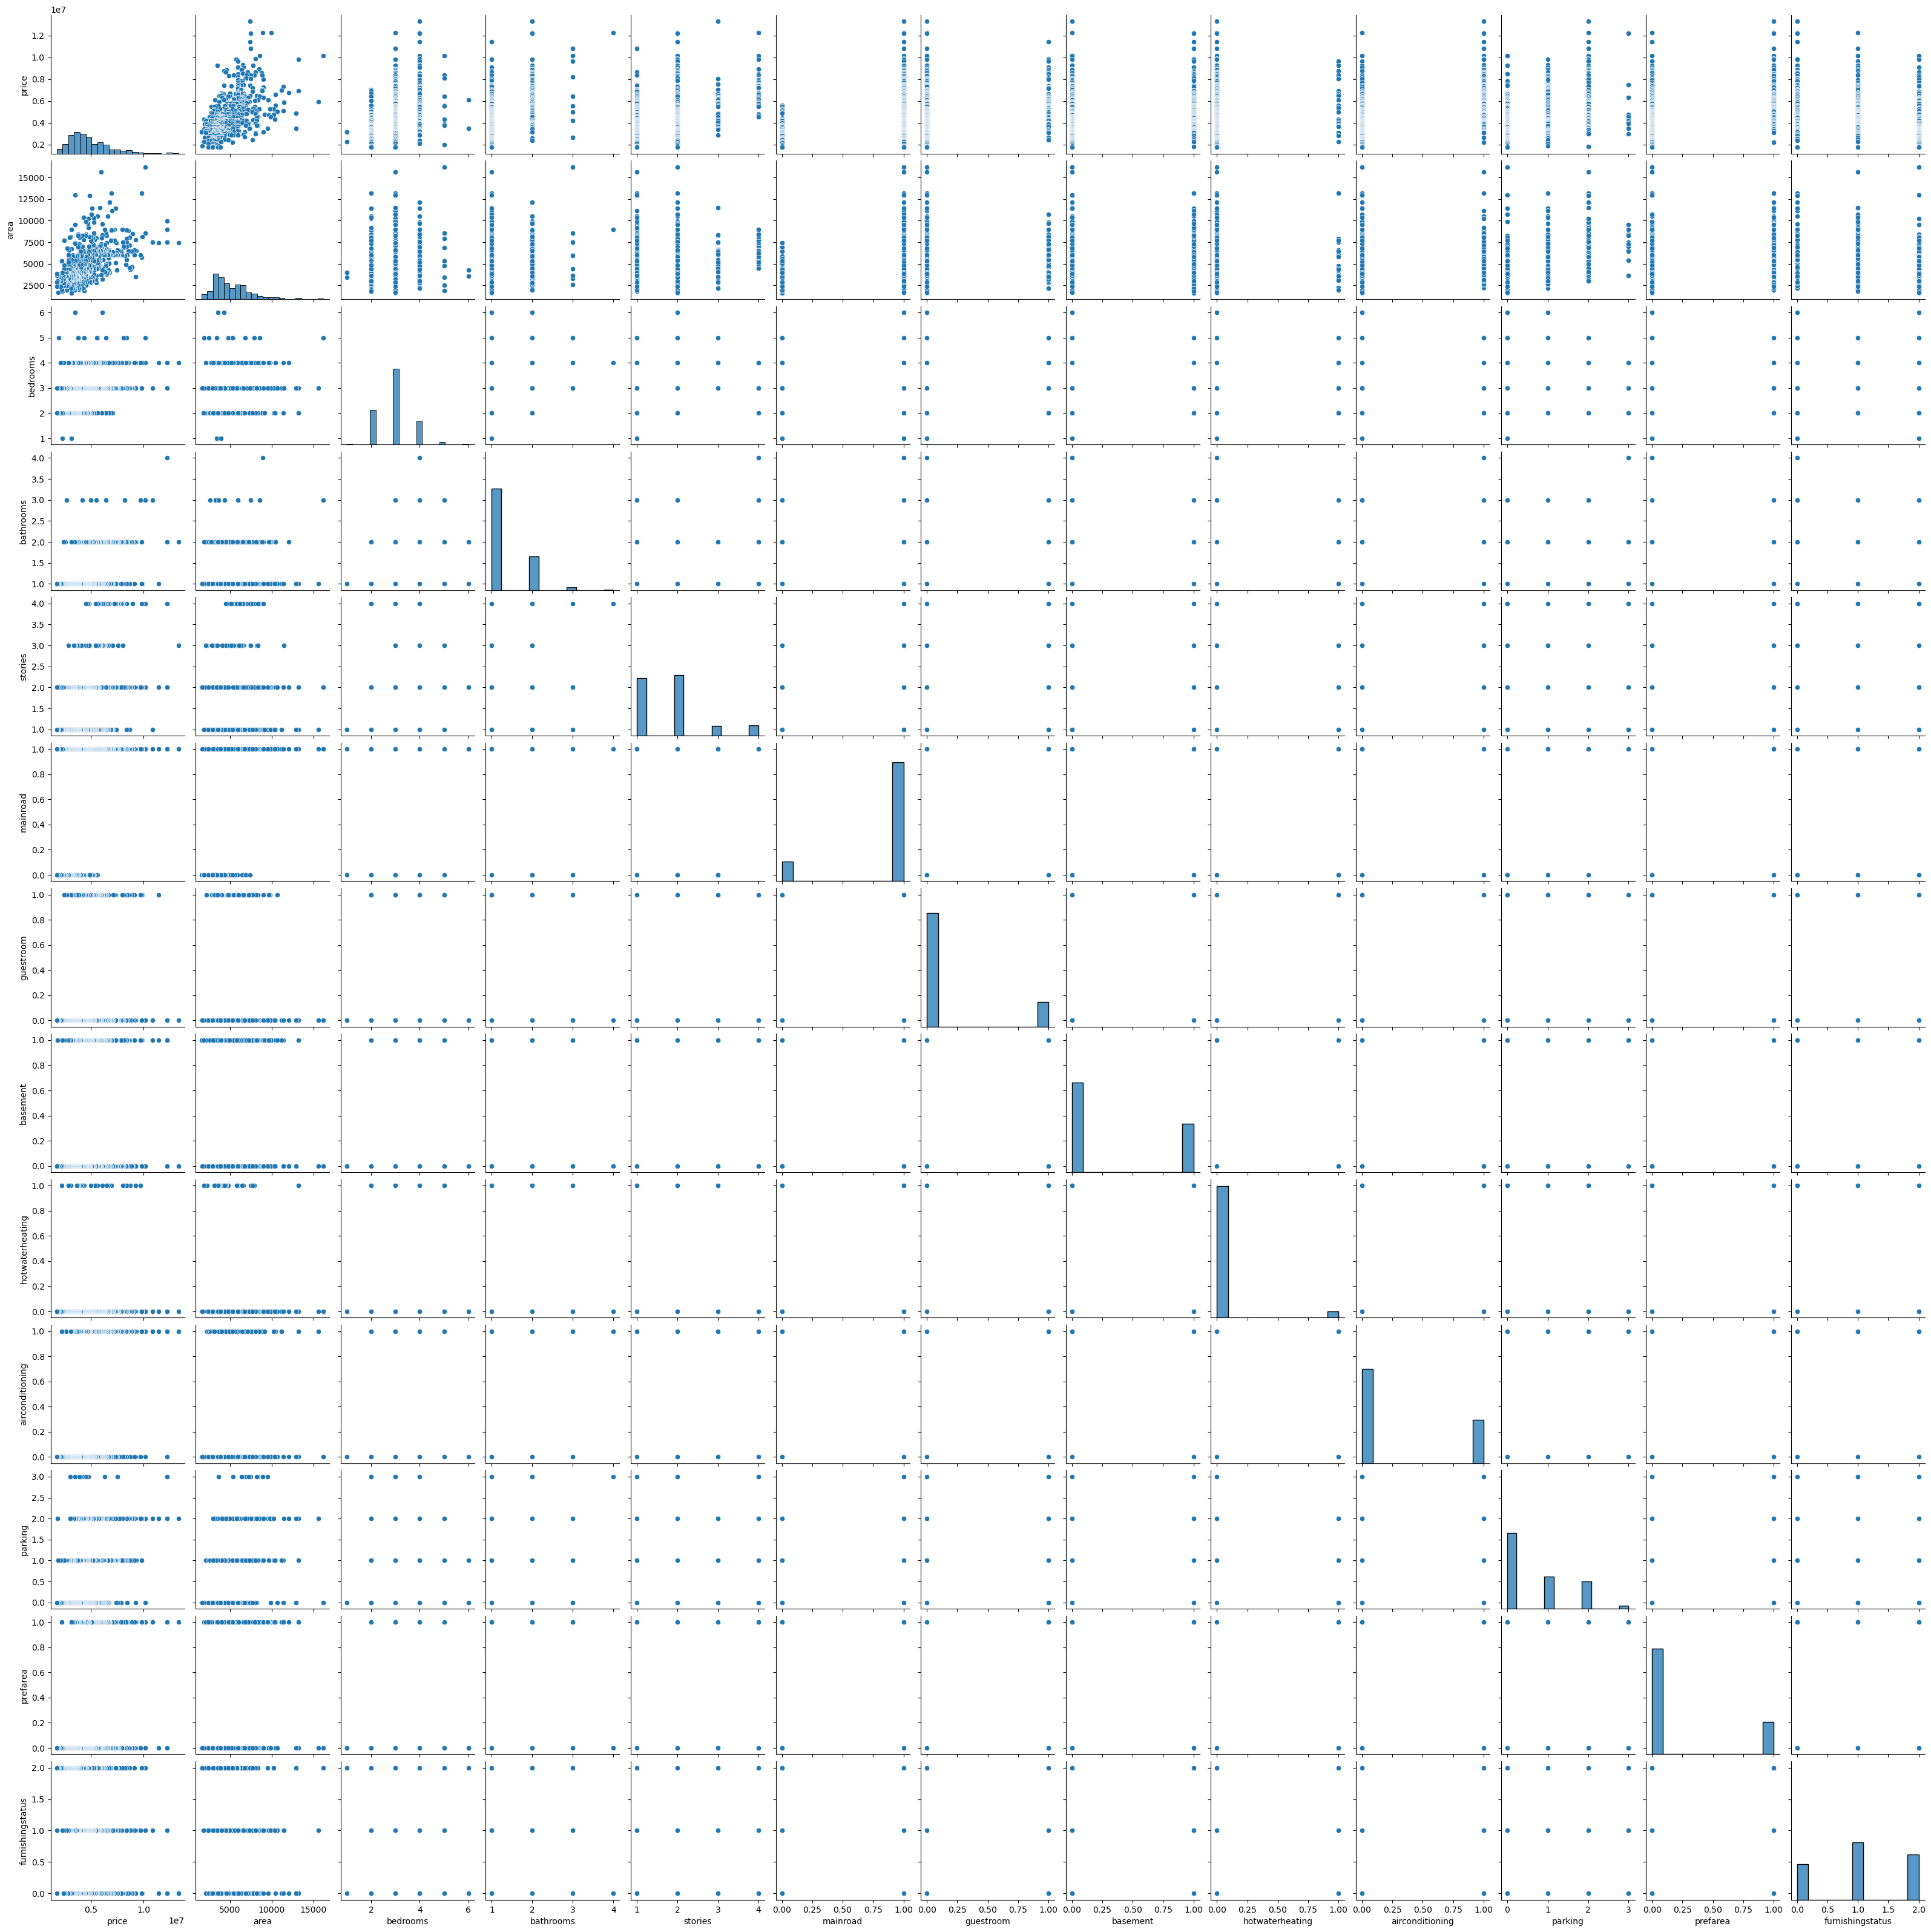

In [16]:
sns.pairplot(df)

<Axes: >

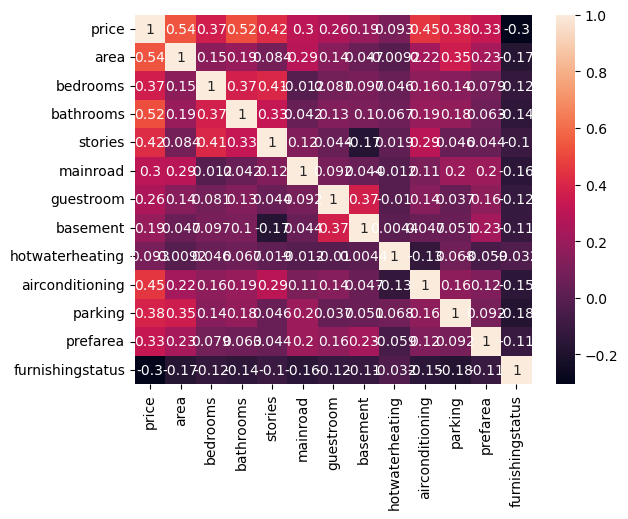

In [30]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='price', ylabel='Count'>

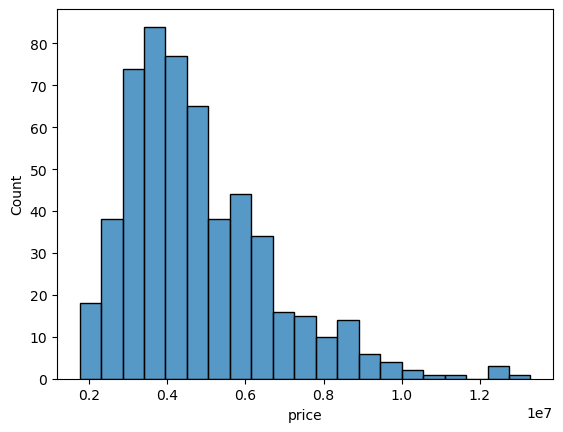

In [31]:
sns.histplot(df["price"])

<Axes: xlabel='area', ylabel='price'>

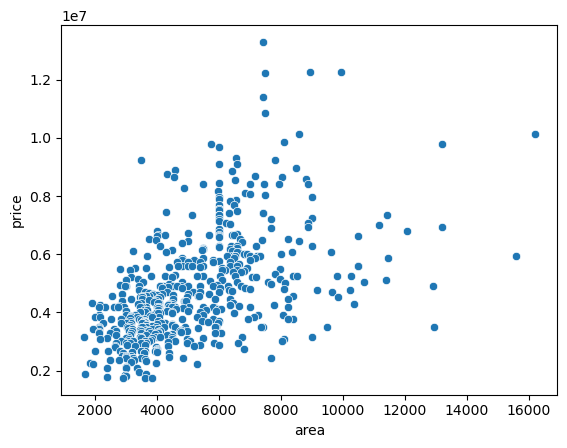

In [34]:
sns.scatterplot(x="area", y="price", data=df)

In [36]:
new_house = [[7420, 4, 2, 3, 1, 0, 1, 0, 1, 2, 1, 0]]
prediction = model.predict(new_house)

print(prediction)

[8397232.19026585]


C:\Users\Hp\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


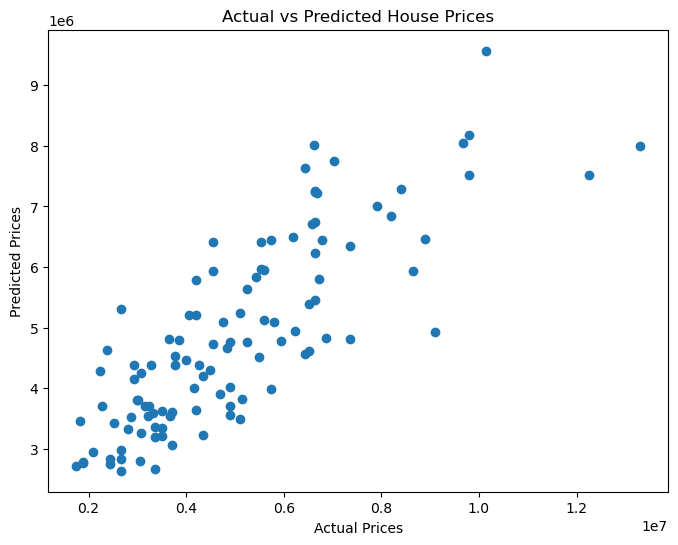

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

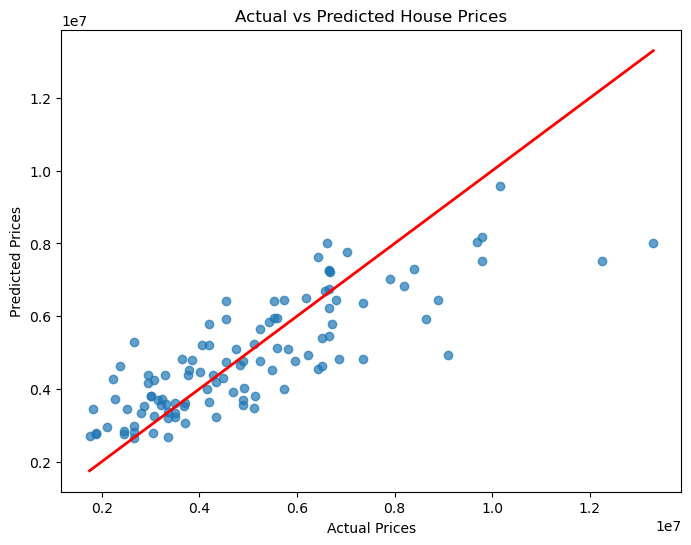

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [47]:
%pwd

'C:\\Users\\Hp\\Mini Projects'